In [1]:
import pandas as pd 
import numpy as np
import random
import math
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.metrics.pairwise import haversine_distances


In [2]:
# Check your version
import sklearn
print(sklearn.__version__)

1.8.0


c:\Users\Lenovo\anaconda3\envs\vrp_env\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


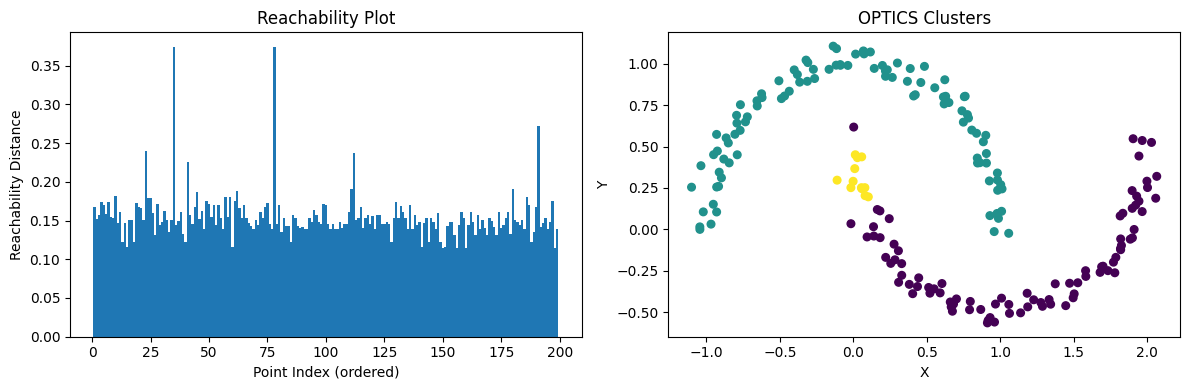

Clusters found: 2
Noise points: 88


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import OPTICS
from sklearn.datasets import make_moons

# Generate sample data
X, _ = make_moons(n_samples=200, noise=0.05, random_state=42)

# Run OPTICS
optics = OPTICS(min_samples=10, xi=0.15, cluster_method='xi')
optics.fit(X)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Reachability plot
axes[0].bar(range(len(optics.reachability_)), optics.reachability_, width=1.0)
axes[0].set_ylabel('Reachability Distance')
axes[0].set_xlabel('Point Index (ordered)')
axes[0].set_title('Reachability Plot')

# Right: Actual clusters
scatter = axes[1].scatter(X[:, 0], X[:, 1], c=optics.labels_, cmap='viridis', s=30)
axes[1].set_title('OPTICS Clusters')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')

plt.tight_layout()
plt.show()

# Print cluster info
print(f"Clusters found: {len(set(optics.labels_)) - (1 if -1 in optics.labels_ else 0)}")
print(f"Noise points: {list(optics.labels_).count(-1)}")

In [4]:
from sklearn.metrics import silhouette_score

scores = []
for xi in [0.01, 0.03, 0.05, 0.1]:
    optics = OPTICS(min_samples=10, xi=xi, cluster_method='xi')
    labels = optics.fit_predict(X)
    if len(set(labels)) > 1:  # need at least 2 clusters
        score = silhouette_score(X, labels)
        scores.append((xi, score))
        print(f"xi={xi}: silhouette={score:.3f}")

xi=0.01: silhouette=0.150
xi=0.03: silhouette=0.251
xi=0.05: silhouette=0.287
xi=0.1: silhouette=0.158


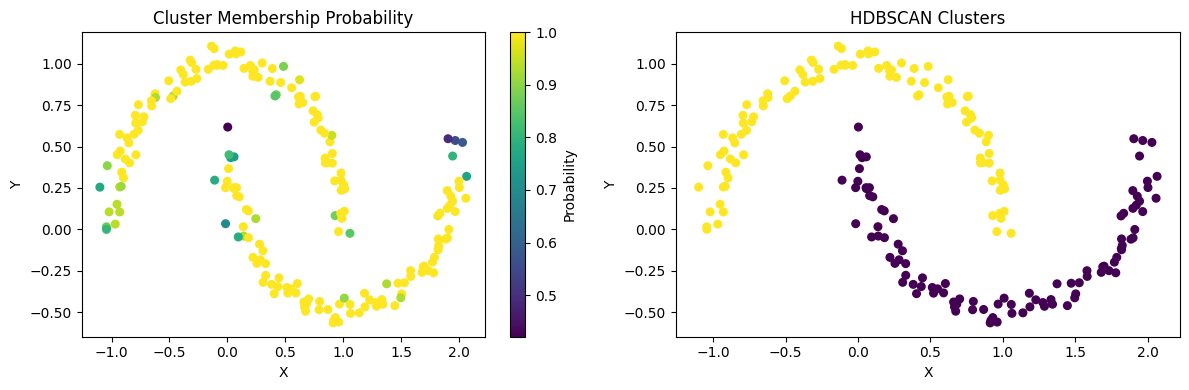

Clusters found: 2
Noise points: 0
DBCV Score: 0.316771898889682


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from hdbscan import HDBSCAN

# Generate sample data
X, _ = make_moons(n_samples=200, noise=0.05, random_state=42)

# Run HDBSCAN (only once)
clusterer = HDBSCAN(min_cluster_size=5, gen_min_span_tree=True)
clusterer.fit(X)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Cluster probabilities (confidence)
scatter1 = axes[0].scatter(X[:, 0], X[:, 1], c=clusterer.probabilities_, cmap='viridis', s=30)
axes[0].set_title('Cluster Membership Probability')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
plt.colorbar(scatter1, ax=axes[0], label='Probability')

# Right: Actual clusters
scatter2 = axes[1].scatter(X[:, 0], X[:, 1], c=clusterer.labels_, cmap='viridis', s=30)
axes[1].set_title('HDBSCAN Clusters')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')

plt.tight_layout()
plt.show()

# Print cluster info
print(f"Clusters found: {len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)}")
print(f"Noise points: {list(clusterer.labels_).count(-1)}")
print(f"DBCV Score: {clusterer.relative_validity_}")

In [6]:
print(f"Total points: {len(X)}")
print(f"Noise points: {list(clusterer.labels_).count(-1)}")
print(f"Cluster labels: {set(clusterer.labels_)}")

Total points: 200
Noise points: 0
Cluster labels: {np.int64(0), np.int64(1)}


In [7]:
for min_size in [5, 10, 15, 20, 30]:
    clusterer = HDBSCAN(min_cluster_size=min_size, gen_min_span_tree=True)
    clusterer.fit(X)
    noise = list(clusterer.labels_).count(-1)
    n_clusters = len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)
    print(f"min_cluster_size={min_size}: clusters={n_clusters}, noise={noise}, DBCV={clusterer.relative_validity_:.4f}")

min_cluster_size=5: clusters=2, noise=0, DBCV=0.3168
min_cluster_size=10: clusters=2, noise=1, DBCV=0.0064
min_cluster_size=15: clusters=2, noise=12, DBCV=0.0040
min_cluster_size=20: clusters=2, noise=26, DBCV=0.0105
min_cluster_size=30: clusters=2, noise=75, DBCV=0.0000


In [8]:
df = pd.read_excel('Input\\Sample data.xlsx')
print(f"Shape of df : {df.shape}")
print(f"df columns : {df.columns}")
df.head()

Shape of df : (72231, 29)
df columns : Index(['loan_id', 'client_id', 'loan_status_id', 'disbursedon_date',
       'closedon_date', 'expected_maturedon_date', 'address_region_value_id',
       'office_id_x', 'Branch', 'finflux_address_id', 'township',
       'ward_village', 'branch2', 'branch_code', 'village_latitude',
       'village_longitude', 'latitude_branch', 'longitude_branch',
       'repayment_schedule_id', 'due_date', 'assigned_loan_officer_id',
       'start_date', 'end_date', 'office_id_y', 'loan_officer',
       'employee_number', 'distance_km', 'bearing_deg', 'direction'],
      dtype='str')


,loan_id,client_id,loan_status_id,disbursedon_date,closedon_date,expected_maturedon_date,address_region_value_id,office_id_x,Branch,finflux_address_id,...,due_date,assigned_loan_officer_id,start_date,end_date,office_id_y,loan_officer,employee_number,distance_km,bearing_deg,direction
0,2177483,593231,300,2025-08-14,NaN,2026-08-10,449556,94,Yamethin,449556,...,2025-09-10,3630,NaN,NaN,94,"Lwin, Moe Aung -1_FO_RT",23091566,4.68,70.504558,E
1,2177130,493299,300,2025-08-13,NaN,2026-08-12,474618,114,Einme,474618,...,2025-09-10,4230,NaN,NaN,114,"Hnin, Ei Phyu - 3_FO_BT",24101345,28.15,204.145642,SW
2,2177095,139084,300,2025-08-14,NaN,2028-02-10,453266,64,Magway,453266,...,2025-09-10,4536,NaN,NaN,64,"Thae, Pwint Phue_FO_RT",25051516,24.27,76.540297,E
3,2177094,139014,300,2025-08-14,NaN,2027-08-10,453266,64,Magway,453266,...,2025-09-10,3977,NaN,NaN,64,"Ei, Shwe Sin -2_FO_RT",24031088,24.27,76.540297,E
4,2176750,593117,300,2025-08-13,NaN,2026-08-12,474602,114,Einme,474602,...,2025-09-10,4401,NaN,NaN,114,"Khant, Si Thu - 2_FO_BT",25011404,16.62,196.282498,S


In [9]:
print(f"df columns : {df.columns}")

df columns : Index(['loan_id', 'client_id', 'loan_status_id', 'disbursedon_date',
       'closedon_date', 'expected_maturedon_date', 'address_region_value_id',
       'office_id_x', 'Branch', 'finflux_address_id', 'township',
       'ward_village', 'branch2', 'branch_code', 'village_latitude',
       'village_longitude', 'latitude_branch', 'longitude_branch',
       'repayment_schedule_id', 'due_date', 'assigned_loan_officer_id',
       'start_date', 'end_date', 'office_id_y', 'loan_officer',
       'employee_number', 'distance_km', 'bearing_deg', 'direction'],
      dtype='str')


In [10]:
df = df[['client_id','finflux_address_id','village_latitude',
       'village_longitude', 'latitude_branch', 'longitude_branch', 
       'due_date', 'assigned_loan_officer_id','Branch']]
print(f"After selecting relevant columns : {df.columns}")
df.head()

After selecting relevant columns : Index(['client_id', 'finflux_address_id', 'village_latitude',
       'village_longitude', 'latitude_branch', 'longitude_branch', 'due_date',
       'assigned_loan_officer_id', 'Branch'],
      dtype='str')


,client_id,finflux_address_id,village_latitude,village_longitude,latitude_branch,longitude_branch,due_date,assigned_loan_officer_id,Branch
0,593231,449556,20.451191,96.183029,20.437149,96.140682,2025-09-10,3630,Yamethin
1,493299,474618,16.669941,95.070389,16.900944,95.178472,2025-09-10,4230,Einme
2,139084,453266,20.194349,95.168961,20.143691,94.942793,2025-09-10,4536,Magway
3,139014,453266,20.194349,95.168961,20.143691,94.942793,2025-09-10,3977,Magway
4,593117,474602,16.757484,95.134712,16.900944,95.178472,2025-09-10,4401,Einme


In [11]:
FO_by_branch = df.groupby('Branch').agg({'assigned_loan_officer_id':'nunique'}).reset_index()
print(FO_by_branch)

            Branch  assigned_loan_officer_id
0           Dedaye                        10
1            Einme                        14
2           Hmawbi                         8
3      Kangyidaunt                        12
4         Kyaiklat                        10
5         Kyauktan                         6
6           Magway                        15
7           Maubin                         9
8   Mawlamyinegyun                        16
9         Meiktila                         7
10       Nyaungdon                         9
11        Pantanaw                        10
12         Pathein                         8
13         Pyawbwe                        13
14      Thein Phyu                        15
15        Yamethin                         9
16           Zalun                        10


In [ ]:
df = df[['client_id','village_latitude','village_longitude', 'due_date', 'Branch',
         'latitude_branch', 'longitude_branch','assigned_loan_officer_id' ]]
df.columns = ['client_id', 'client_latitude','client_longitude',  'due_date', 'Branch',
              'latitude_branch', 'longitude_branch','assigned_loan_officer_id']
df["due_date"] = pd.to_datetime(df["due_date"])

cycle_start = pd.Timestamp("2024-01-01") # this date can be adjusted as needed

df["cycle_day"] = (
    (df["due_date"] - cycle_start).dt.days % 28
) + 1

df.head()

In [ ]:
Dedaye_df = df[df['Branch']=='Dedaye']
print(f"Shape of Dedaye_df : {Dedaye_df.shape}")

In [ ]:
print(f"Number of unique clients: {Dedaye_df['client_id'].nunique()}")

In [ ]:
Dedaye_df['due_date'] = pd.to_datetime(Dedaye_df['due_date']).dt.date
Dedaye_df['due_date'] = Dedaye_df['due_date'].astype(str)

In [ ]:
Dedaye_df.groupby('due_date').agg({'assigned_loan_officer_id':'nunique'})

In [ ]:
office_location = Dedaye_df[['latitude_branch', 'longitude_branch']].drop_duplicates()
office_location['Name'] = 'Dedaye_Office'
office_location = office_location.rename(columns={'latitude_branch':'Latitude', 'longitude_branch':'Longitude'})
office_location['Type'] = 'Office'

In [ ]:
# make separate dataframes for each due_date from Dedaye_df
Dedaye_due_dates = Dedaye_df['due_date'].unique().tolist()
Dedaye_date_dfs = {}
for due_date in Dedaye_due_dates:
    Dedaye_date_dfs[due_date] = Dedaye_df[Dedaye_df['due_date']==due_date][['client_id', 'client_latitude', 'client_longitude']]
    Dedaye_date_dfs[due_date] = Dedaye_date_dfs[due_date].rename(columns={'client_id':'Name', 'client_latitude':'Latitude', 'client_longitude':'Longitude'})
    Dedaye_date_dfs[due_date]['Type'] = 'Client'
    Dedaye_date_dfs[due_date] = pd.concat([Dedaye_date_dfs[due_date], office_location[['Name', 'Latitude', 'Longitude', 'Type']]], ignore_index=True)
    # print(f"  Shape of Dedaye_date_dfs[{due_date}] : {Dedaye_date_dfs[due_date].shape}")
    Dedaye_date_dfs[due_date] = Dedaye_date_dfs[due_date].drop_duplicates(subset=['Latitude', 'Longitude'])
    print(f"Shape of Dedaye_date_dfs[{due_date}] : {Dedaye_date_dfs[due_date]}")
    print("____________________________________________________________")
    
